In [ ]:
import pandas as pd
# Based on UNB NSL-KDD Documentation
# Step 1: Define column names
column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
    'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate',
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]



In [6]:
# Step 2: Load datasets
train_path = "C:/Users/masri/OneDrive - Asia Pacific University of Technology And Innovation (APU)/SEM1/AML/Assignment AML MASTERS/archive/KDDTrain+.txt"  
test_path  = "C:/Users/masri/OneDrive - Asia Pacific University of Technology And Innovation (APU)/SEM1/AML/Assignment AML MASTERS/archive/KDDTest+.txt"   

train_df = pd.read_csv(train_path, names=column_names)
test_df  = pd.read_csv(test_path, names=column_names)
# Step 3: Basic info
print("=== TRAIN DATASET INFO ===")
print("Shape:", train_df.shape)
print("\nMissing values:\n", train_df.isnull().sum())
print("\nClass distribution:\n", train_df['label'].value_counts())

print("\n=== TEST DATASET INFO ===")
print("Shape:", test_df.shape) #Lect nak at least 6-7k
print("\nMissing values:\n", test_df.isnull().sum())
print("\nClass distribution:\n", test_df['label'].value_counts())


=== TRAIN DATASET INFO ===
Shape: (125973, 43)

Missing values:
 duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_ra

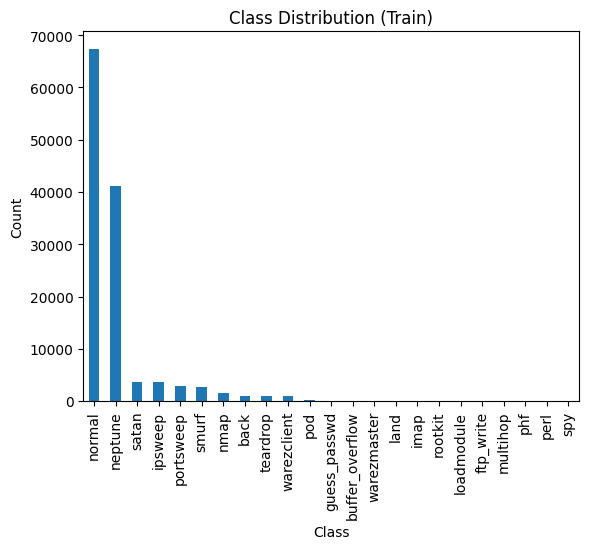

['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy' 'perl']


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
#class distribution visualization
plt.figure()
train_df['label'].value_counts().plot(kind='bar')
plt.title("Class Distribution (Train)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()
print(train_df['label'].unique())

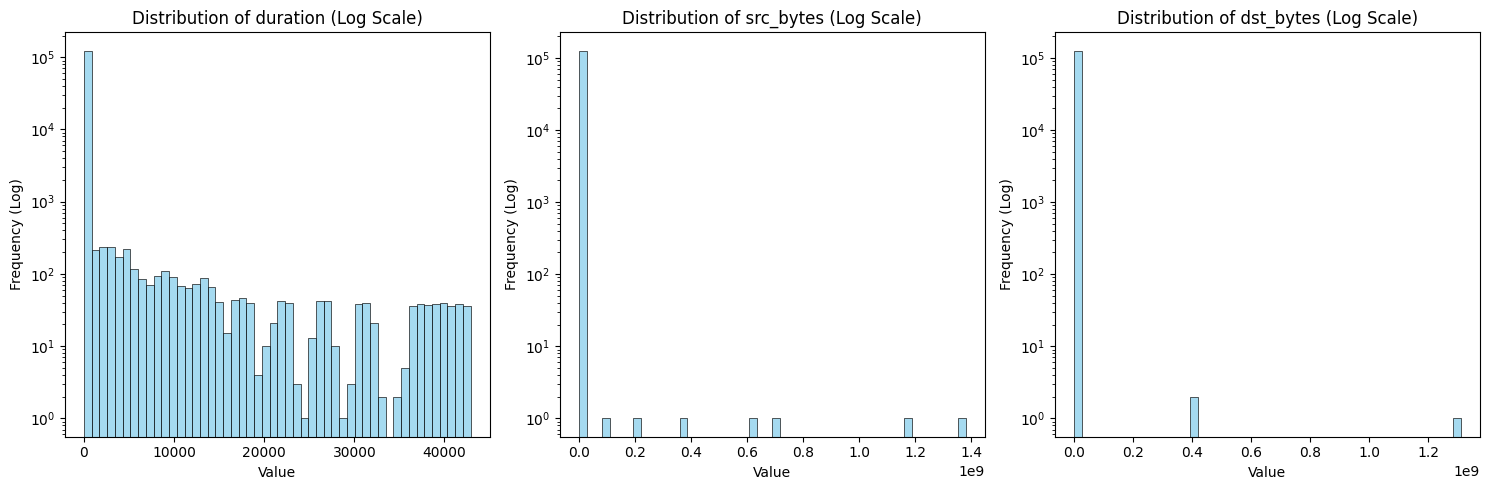

In [8]:
# Select the features mentioned in your report
skewed_features = ['duration', 'src_bytes', 'dst_bytes']

plt.figure(figsize=(15, 5))
for i, col in enumerate(skewed_features):
    plt.subplot(1, 3, i+1)
    sns.histplot(train_df[col], bins=50, kde=False, color='skyblue')
    plt.yscale('log') # Vital because of extreme outliers
    plt.title(f'Distribution of {col} (Log Scale)')
    plt.xlabel('Value')
    plt.ylabel('Frequency (Log)')

plt.tight_layout()
plt.show()

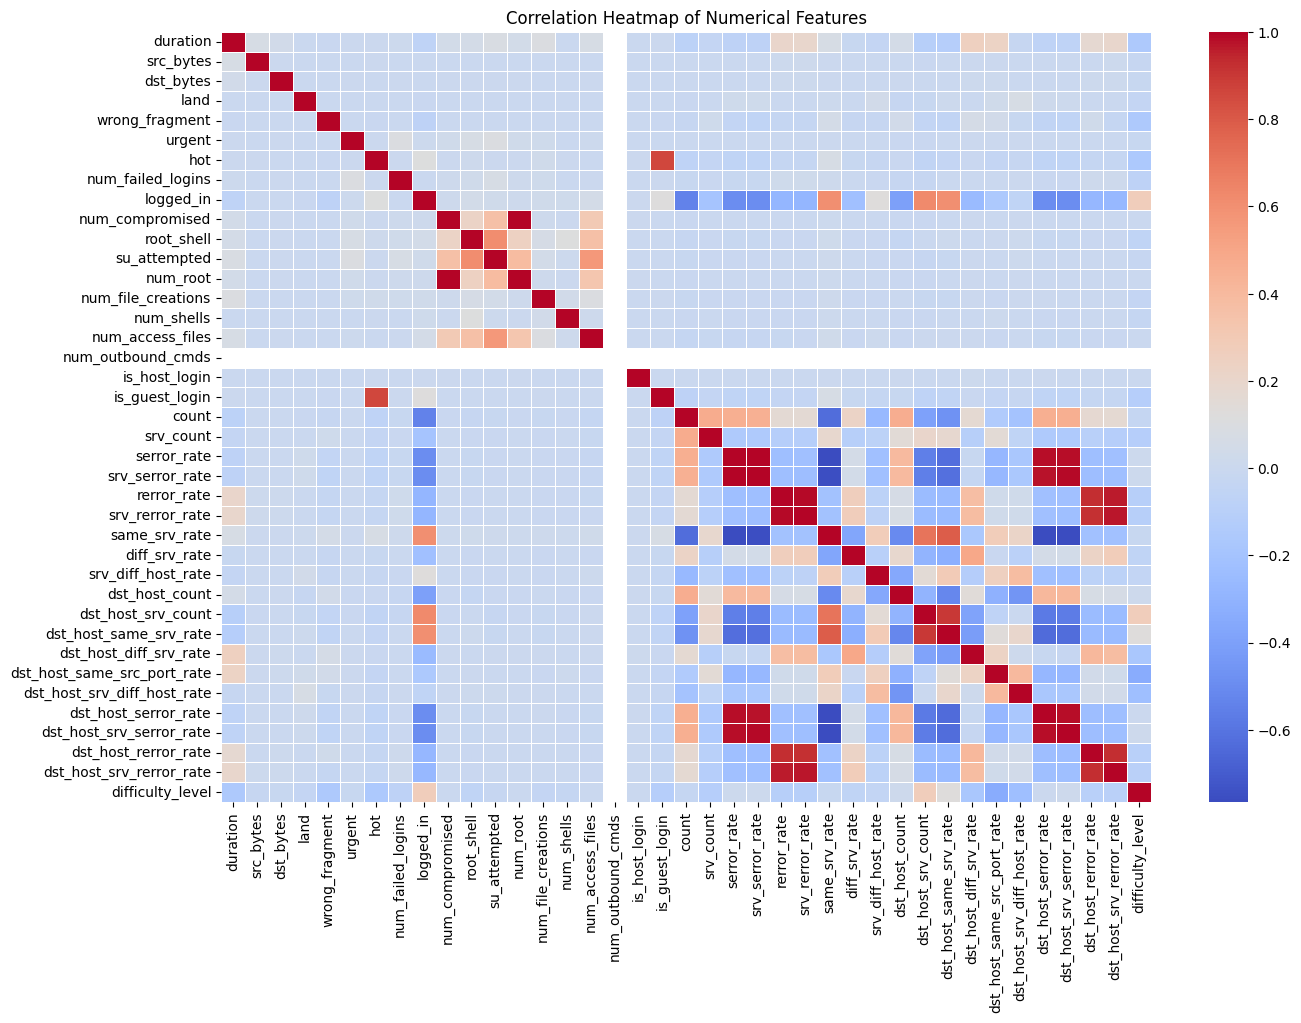

In [9]:
# Select only numerical columns for correlation
numeric_df = train_df.select_dtypes(include=['number'])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

# Insight for report: Look for dark red/blue squares to find redundant features

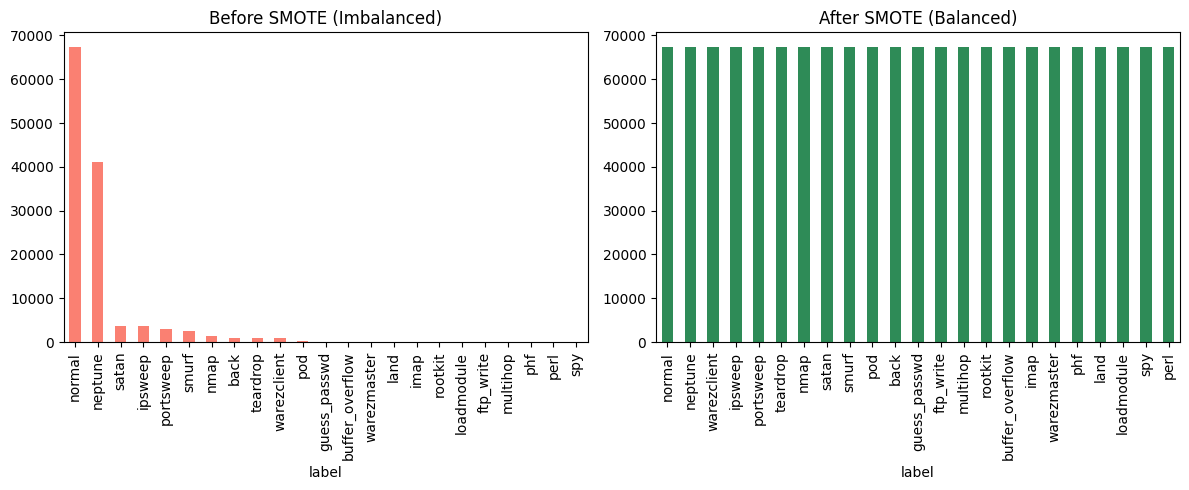

In [10]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

# 1. Quick Encoding for SMOTE (SMOTE only works with numbers)
train_encoded = train_df.copy()
for col in ['protocol_type', 'service', 'flag']:
    train_encoded[col] = LabelEncoder().fit_transform(train_encoded[col])

# 2. Define X and y (using the major classes or specific labels)
X = train_encoded.drop(['label', 'difficulty_level'], axis=1)
y = train_encoded['label']

# 3. Apply SMOTE
sm = SMOTE(sampling_strategy='auto', k_neighbors=1) # k=1 because some classes are tiny
X_res, y_res = sm.fit_resample(X, y)

# 4. Visualization: Before vs After
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
y.value_counts().plot(kind='bar', color='salmon')
plt.title("Before SMOTE (Imbalanced)")

plt.subplot(1, 2, 2)
pd.Series(y_res).value_counts().plot(kind='bar', color='seagreen')
plt.title("After SMOTE (Balanced)")

plt.tight_layout()
plt.show()

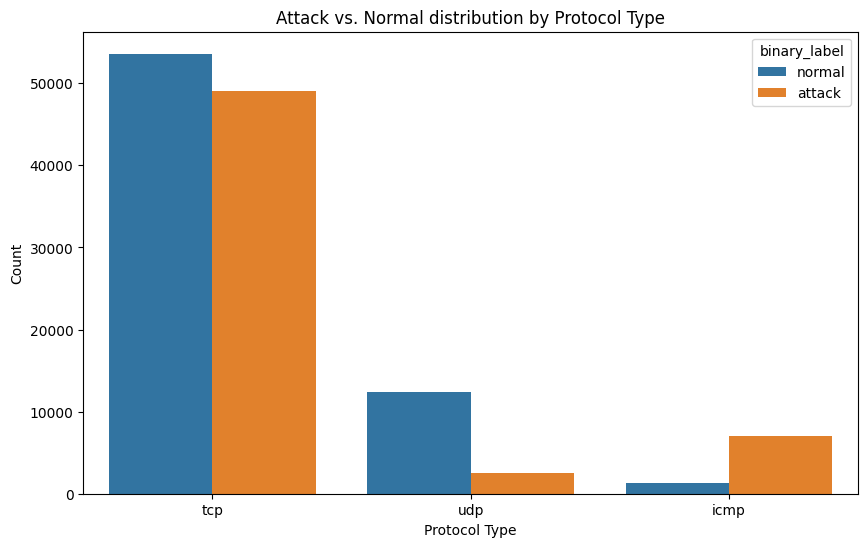

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

#Protocol and Service Analysis (Categorical EDA)
train_df['binary_label'] = train_df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

plt.figure(figsize=(10, 6))
sns.countplot(x='protocol_type', hue='binary_label', data=train_df)
plt.title("Attack vs. Normal distribution by Protocol Type")
plt.xlabel("Protocol Type")
plt.ylabel("Count")
plt.show()

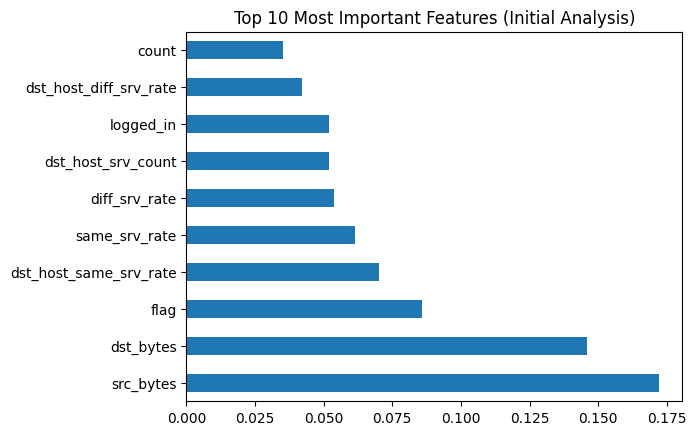

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Temporary encoding for EDA
df_temp = train_df.copy()
for col in ['protocol_type', 'service', 'flag']:
    df_temp[col] = LabelEncoder().fit_transform(df_temp[col])

X_temp = df_temp.drop(['label', 'difficulty_level', 'binary_label'], axis=1)
y_temp = df_temp['binary_label']

model_temp = RandomForestClassifier().fit(X_temp, y_temp)

# Plot top 10 features
#to identify the most discriminative attributes, reducing noise in the final ensemble models.
feat_importances = pd.Series(model_temp.feature_importances_, index=X_temp.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Most Important Features (Initial Analysis)")
plt.show()

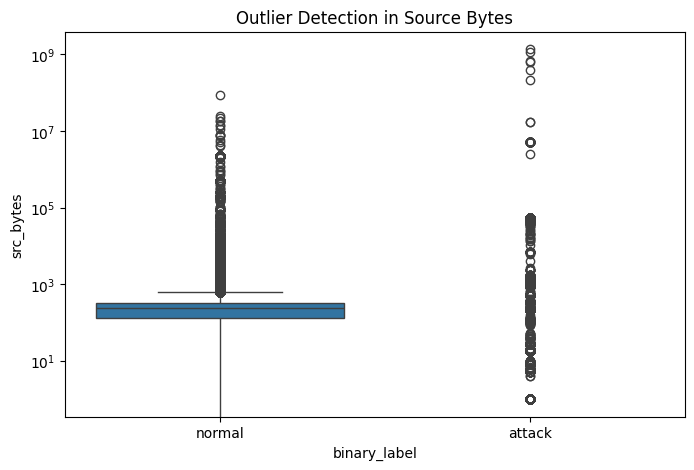

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='binary_label', y='src_bytes', data=train_df)
plt.yscale('log')
plt.title("Outlier Detection in Source Bytes")
plt.show()